In [9]:
import pandas as pd
import geopandas as gpd
import folium
import json

# ─────────────────────────────────────────
# 1. 3개월치 로드 & 원지표 평균
# ─────────────────────────────────────────
df_list = []
for month in ['202206', '202207', '202208']:
    df = pd.read_csv(f'../data/HVI_final/HVI_bnd_dong_{month}_final.xls', dtype={'hdong_code': str})
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

df_avg = df_all.groupby(['hdong_code', 'gu_name', 'hdong_name'])[
    ['low_ratio_combined', 'old_ratio', 'unit_density']
].mean().reset_index()


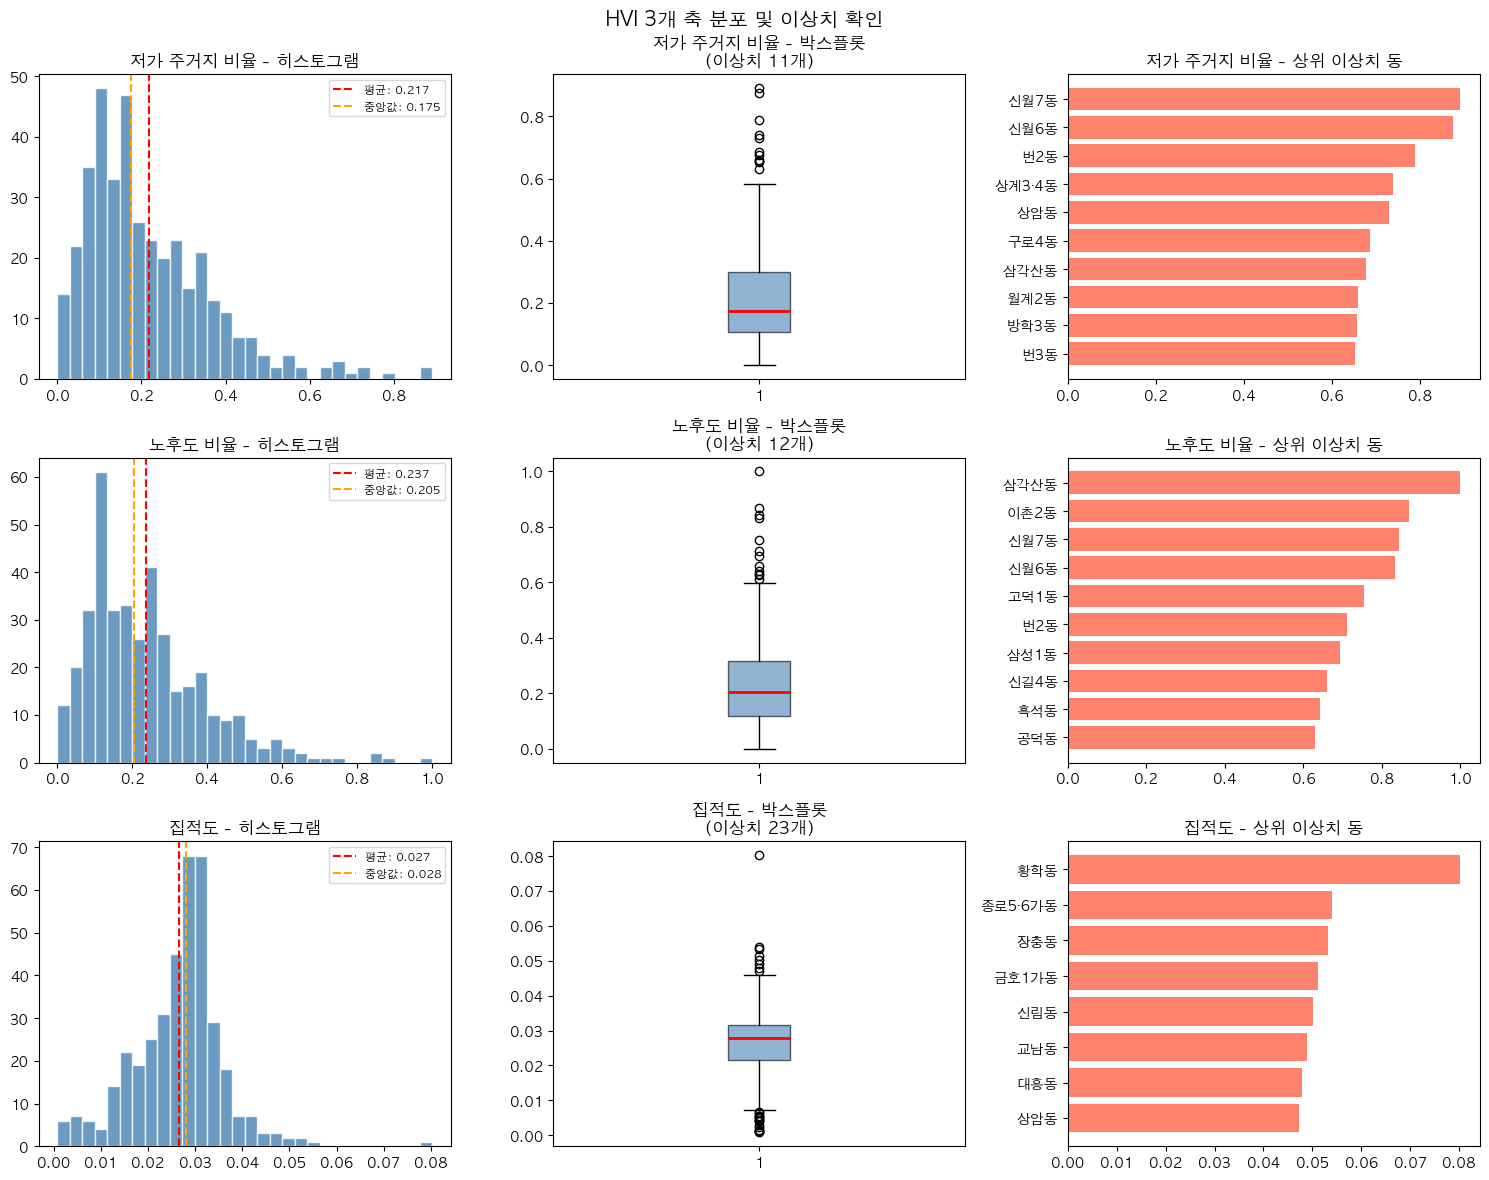

In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('HVI 3개 축 분포 및 이상치 확인', fontsize=14, fontweight='bold')

cols = {
    'low_ratio_combined': '저가 주거지 비율',
    'old_ratio': '노후도 비율',
    'unit_density': '집적도'
}

for i, (col, label) in enumerate(cols.items()):
    data = df_avg[col].dropna()
    
    # 1열: 히스토그램
    ax1 = axes[i][0]
    ax1.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'평균: {data.mean():.3f}')
    ax1.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {data.median():.3f}')
    ax1.set_title(f'{label} - 히스토그램')
    ax1.legend(fontsize=8)

    # 2열: 박스플롯
    ax2 = axes[i][1]
    ax2.boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
    
    # IQR 기준 이상치 표시
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    ax2.set_title(f'{label} - 박스플롯\n(이상치 {len(outliers)}개)')

    # 3열: 이상치 행정동 Top10
    ax3 = axes[i][2]
    upper_out = df_avg[df_avg[col] > Q3 + 1.5*IQR][['hdong_name', col]].sort_values(col, ascending=False).head(10)
    if len(upper_out) > 0:
        ax3.barh(upper_out['hdong_name'], upper_out[col], color='tomato', alpha=0.8)
        ax3.set_title(f'{label} - 상위 이상치 동')
        ax3.invert_yaxis()
    else:
        ax3.text(0.5, 0.5, '이상치 없음', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title(f'{label} - 상위 이상치 동')

plt.tight_layout()
plt.savefig('HVI_distribution_check.png', dpi=150, bbox_inches='tight')
plt.show()

- 저가주거지, 노후도 : 오른쪽으로 꼬리가 긴 분포, 값이 평균 중앙값보다 많이 큰 outlier 다수 존재
- 집적도 : 비교적 안정. 근데 그냥 원점수로 min_max sclaing하기엔 황학동이 비정상적으로 집적도가 높음

In [12]:
from scipy.stats import rankdata

for col, score_col in [
    ('low_ratio_combined', 'score_low'),
    ('old_ratio',          'score_old'),
    ('unit_density',       'score_density')
]:
    # 전체 분포에서 각 행정동의 백분위 (0~100)
    df_avg[score_col] = (rankdata(df_avg[col], method='average') - 1) / (len(df_avg) - 1) * 100

# 3개 축 합산 후 평균 → 0~100
df_avg['HVI_score'] = (df_avg['score_low'] + df_avg['score_old'] + df_avg['score_density']) / 3
df_avg['HVI_index'] = df_avg['HVI_score'].round().astype(int)

In [ ]:
df_avg['HVI_index'].describe()
# HVI_index 분포 확인 : 대칭 분포, 이상치 영향 거의 없음

count    388.000000
mean      49.984536
std       16.655028
min        0.000000
25%       38.000000
50%       50.000000
75%       62.000000
max       94.000000
Name: HVI_index, dtype: float64

In [15]:
df_avg['HVI_rank'] = df_avg['HVI_index'].rank(ascending=False, method='min').astype(int)
df_avg['HVI_grade'] = pd.qcut(df_avg['HVI_index'], q=5,
                               labels=['매우낮음','낮음','보통','높음','매우높음'])

In [18]:
len(df_avg)

388

In [16]:
import geopandas as gpd
import folium
import json

# shapefile 로드
gdf = gpd.read_file('../data/hdong_data/bnd_dong_11_2025_2Q/bnd_dong_11_2025_2Q.shp')
gdf = gdf.to_crs(epsg=4326)
gdf = gdf.rename(columns={'ADM_CD': 'hdong_code', 'ADM_NM': 'hdong_name'})
gdf['hdong_code'] = gdf['hdong_code'].astype(str)

# HVI 병합
df_avg['hdong_code'] = df_avg['hdong_code'].astype(str)
gdf_merged = gdf.merge(df_avg, on='hdong_code', how='left')

# 병합 누락 확인
missing = gdf_merged[gdf_merged['HVI_index'].isna()]['hdong_name_x'].tolist()
print(f"매핑 안 된 행정동 {len(missing)}개: {missing[:5]}")

# 지도
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=json.loads(gdf_merged.to_json()),
    data=df_avg,
    columns=['hdong_code', 'HVI_index'],
    key_on='feature.properties.hdong_code',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='HVI 주거취약지수 (0~100)',
    nan_fill_color='lightgray'
).add_to(m)

# 툴팁
folium.GeoJson(
    json.loads(gdf_merged.to_json()),
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['hdong_name_x', 'gu_name', 'HVI_index', 'HVI_rank', 'HVI_grade'],
        aliases=['행정동', '자치구', 'HVI 점수', '순위', '등급'],
        localize=True
    )
).add_to(m)

m.save('HVI_choropleth.html')
print("저장 완료: HVI_choropleth.html")

매핑 안 된 행정동 38개: ['종로1·2·3·4가동', '소공동', '명동', '을지로동', '이촌1동']
저장 완료: HVI_choropleth.html


In [17]:
missing_dong = gdf_merged[gdf_merged['HVI_index'].isna()][['hdong_name_x', 'hdong_code']].sort_values('hdong_name_x')
print(f"총 {len(missing_dong)}개 행정동 누락:")
print(missing_dong.to_string(index=False))

총 38개 행정동 누락:
hdong_name_x hdong_code
        가락1동   11240660
        가양2동   11160650
        가양3동   11160660
         강일동   11250750
        개포3동   11230511
        둔촌1동   11250700
          명동   11020550
         목5동   11150710
        문정2동   11240690
        반포2동   11220580
        반포3동   11220590
        반포본동   11220560
       상계10동   11110740
      상계6·7동   11110770
        상계8동   11110720
        상계9동   11110730
        상일2동   11250770
         소공동   11020520
         수서동   11230750
        신내2동   11070700
        신정6동   11150690
         여의동   11190540
         오륜동   11240590
        월계3동   11110530
         위례동   11240820
        을지로동   11020600
        이촌1동   11030630
        잠실2동   11240790
        잠실3동   11240800
        잠실4동   11240750
        잠실6동   11240770
        잠실7동   11240780
 종로1·2·3·4가동   11010610
        중계1동   11110610
      중계2·3동   11110780
         진관동   11120710
         창4동   11100620
        하계2동   11110590


In [ ]:
# ─────────────────────────────────────────
# 5. 모아센터 오버레이 (데이터 있을 경우)
# ─────────────────────────────────────────
# df_moa = pd.read_csv('moasenter.csv')
# for _, row in df_moa.iterrows():
#     folium.CircleMarker(
#         location=[row['LAT'], row['LNG']],
#         radius=6,
#         color='blue',
#         fill=True,
#         fill_opacity=0.9,
#         popup=row['center_name']
#     ).add_to(m)
# m.save('hvi_with_moa.html')

In [20]:
df = pd.read_csv('../data/HVI_final/HVI_bnd_dong_202206_final.xls', dtype={'hdong_code': str})
print(df[df['hdong_name'].isin(['강일동', '상일동', '상일1동', '상일2동'])][['hdong_code', 'hdong_name']])

    hdong_code hdong_name
387   11250760        상일동


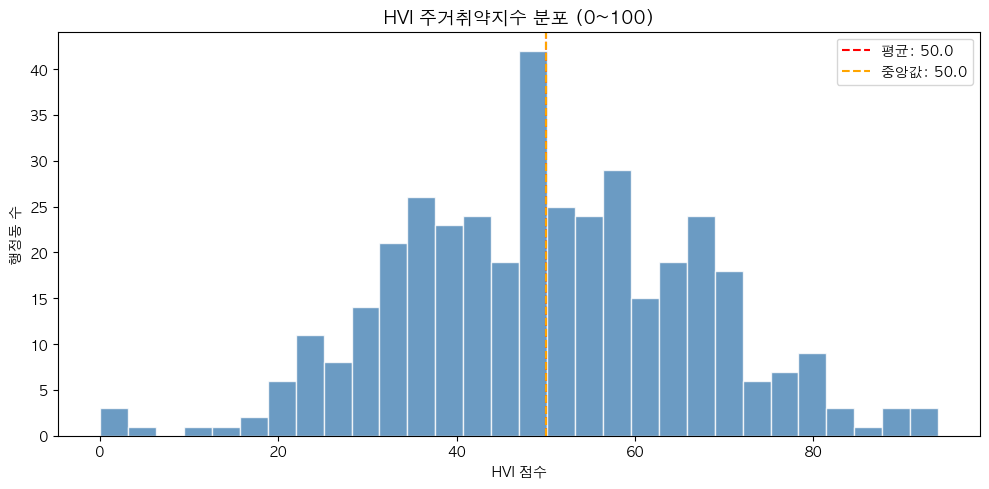

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_avg['HVI_index'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df_avg['HVI_index'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'평균: {df_avg["HVI_index"].mean():.1f}')
ax.axvline(df_avg['HVI_index'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'중앙값: {df_avg["HVI_index"].median():.1f}')

ax.set_title('HVI 주거취약지수 분포 (0~100)', fontsize=13)
ax.set_xlabel('HVI 점수')
ax.set_ylabel('행정동 수')
ax.legend()

plt.tight_layout()
plt.savefig('HVI_index_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# 팀 공유용 CSV
export_team = df_avg[['gu_name', 'hdong_name', 'hdong_code', 'HVI_index']].copy()
export_team = export_team.rename(columns={
    'gu_name': '자치구명',
    'hdong_name': '행정동명',
    'hdong_code': '행정동코드',
    'HVI_index': 'HVI'
}).sort_values(['자치구명', '행정동명']).reset_index(drop=True)

export_team.to_csv('../data/HVI_final/B068_HVI.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {len(export_team)}개 행정동")
print(export_team.head())

저장 완료: 388개 행정동
  자치구명  행정동명     행정동코드  HVI
0  강남구  개포1동  11230680   42
1  강남구  개포2동  11230800   56
2  강남구  개포4동  11230710   44
3  강남구  논현1동  11230520   35
4  강남구  논현2동  11230530   22


In [5]:
import pandas as pd
dff = pd.read_csv('../data/HVI_final/B068_HVI.csv', encoding='utf-8-sig')
print(dff.sort_values(['HVI'],ascending=False).head(20))

     자치구명     행정동명     행정동코드  HVI
291   양천구     신월6동  11150620   94
21    강동구     고덕2동  11250560   92
111   구로구     구로3동  11170540   91
38    강북구      번2동  11090610   89
322   용산구     이촌2동  11030640   89
80    관악구      신원동  11210650   88
152   도봉구      창5동  11100630   87
36    강북구      미아동  11090700   83
245   성북구     길음2동  11080680   83
20    강동구     고덕1동  11250550   82
135   노원구     월계1동  11110510   81
292   양천구     신월7동  11150630   81
246   성북구     돈암1동  11080580   80
202  서대문구     북아현동  11130740   80
343   은평구     응암3동  11120730   80
354   종로구  종로5·6가동  11010630   80
203  서대문구      신촌동  11130750   80
337   은평구      수색동  11120680   79
164  동대문구      회기동  11060710   79
229   성동구    금호4가동  11040620   77


In [8]:
dfff = pd.read_csv('../data/서울시 부동산 실거래가 정보.csv', encoding='cp949')
dfff.head()

,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한 개업공인중개사 시군구명
0,2026,11500,강서구,10200,등촌동,1.0,대지,656.0,0.0,경동미르웰한올림,...,13000,16.190,25.010,4.0,NaN,NaN,2016.0,오피스텔,중개거래,서울 강서구
1,2026,11305,강북구,10300,수유동,1.0,대지,735.0,1.0,한솔그린빌(791-1238),...,20000,65.130,39.000,3.0,NaN,NaN,2007.0,연립다세대,직거래,NaN
2,2026,11545,금천구,10100,가산동,1.0,대지,233.0,5.0,가산센트럴 푸르지오시티,...,11000,17.620,25.321,3.0,NaN,NaN,2020.0,오피스텔,중개거래,서울 금천구
3,2026,11710,송파구,10100,잠실동,1.0,대지,40.0,0.0,갤러리아팰리스,...,69000,50.756,50.756,5.0,NaN,NaN,2005.0,오피스텔,중개거래,서울 송파구
4,2026,11470,양천구,10100,신정동,1.0,대지,978.0,7.0,금정빌(978-7),...,38000,21.170,10.000,3.0,NaN,NaN,2011.0,연립다세대,직거래,NaN


In [9]:
# 연립다세대 필터링 후 법정동별 고유 건물 수
multi = dfff[dfff['건물용도'] == '연립다세대']

dong_building_cnt = (
    multi.groupby(['자치구명', '법정동명'])['건물명']
    .nunique()
    .reset_index()
    .rename(columns={'건물명': '건물수'})
    .sort_values('건물수', ascending=False)
    .reset_index(drop=True)
)

print(f"연립다세대 거래 건수: {len(multi):,}건")
print(f"법정동 수: {dong_building_cnt.shape[0]}개\n")
print(dong_building_cnt.to_string(index=False))

연립다세대 거래 건수: 11,551건
법정동 수: 278개

자치구명   법정동명  건물수
 강서구    화곡동  454
 양천구     목동  300
 동작구    상도동  239
 관악구    봉천동  222
 관악구    신림동  206
 광진구    중곡동  198
 강북구    수유동  178
 양천구    신월동  170
 광진구    구의동  157
 성북구    장위동  149
 동작구    사당동  148
 중랑구    면목동  141
 서초구    방배동  137
 은평구    불광동  136
 광진구    자양동  135
 금천구    독산동  131
 강동구    천호동  130
 은평구    역촌동  113
 은평구    갈현동  108
 구로구    개봉동  103
 양천구    신정동   96
 은평구    신사동   93
서대문구   북가좌동   91
 성북구    정릉동   90
 은평구    구산동   86
 도봉구     창동   85
 송파구    마천동   84
 마포구    망원동   83
 금천구    시흥동   82
 은평구    응암동   82
 송파구    방이동   81
 송파구    석촌동   80
 강북구    미아동   80
 마포구    성산동   79
 은평구    녹번동   78
 강동구    성내동   77
 송파구    삼전동   77
 서초구    양재동   75
 송파구    송파동   75
 도봉구    쌍문동   71
영등포구    신길동   70
 노원구    상계동   69
 송파구    오금동   67
 은평구    대조동   63
 서초구    서초동   63
 강동구    암사동   62
 도봉구    방학동   61
 송파구    문정동   60
 강서구    등촌동   60
 강남구    역삼동   60
  중구    신당동   60
 중랑구     묵동   58
 중랑구    중화동   57
 강서구    방화동   54
 중랑구    상봉동   54
동대문구    장안동   

In [10]:
# 연립다세대 건물 5개 미만 법정동
low_cnt = dong_building_cnt[dong_building_cnt['건물수'] < 5].reset_index(drop=True)
print(f"건물 5개 미만 법정동: {len(low_cnt)}개\n")
print(low_cnt.to_string(index=False))

건물 5개 미만 법정동: 101개

자치구명   법정동명  건물수
영등포구 영등포동6가    4
동대문구    회기동    4
 용산구  원효로1가    4
 용산구    이촌동    4
 은평구    수색동    4
 용산구  청파동2가    4
 성동구    행당동    4
 성동구  하왕십리동    4
 성북구  보문동5가    4
 성동구    사근동    4
 종로구    청운동    4
영등포구  양평동6가    4
 성북구    길음동    4
 성북구  삼선동5가    4
 마포구    대흥동    4
 마포구    당인동    4
 동작구     본동    4
 성북구  성북동1가    4
 종로구    원서동    3
 성북구  삼선동4가    3
 강남구    신사동    3
 용산구  한강로2가    3
 성동구    도선동    3
 성북구  동선동5가    3
 종로구   명륜3가    3
 서초구    잠원동    3
 종로구    옥인동    3
동대문구    신설동    3
영등포구  당산동4가    3
 마포구   신공덕동    3
 종로구    행촌동    3
  중구  장충동1가    3
영등포구 영등포동7가    3
 종로구    동숭동    2
 마포구    현석동    2
 구로구     항동    2
  중구   필동3가    2
 마포구    도화동    2
 마포구    공덕동    2
 마포구    상암동    2
  중구    중림동    2
 종로구    체부동    2
 종로구   명륜2가    2
 종로구    필운동    2
 종로구    연건동    2
 성북구  보문동6가    2
 성북구  안암동4가    2
영등포구 영등포동2가    2
영등포구    당산동    2
 용산구  원효로3가    2
 용산구  원효로4가    2
 용산구    신계동    2
 성북구  동선동4가    2
 강서구    가양동    2
 용산구  원효로2가    2
 동작구    동작동    2
 용산구    보광동

In [16]:
import pandas as pd

df = pd.read_csv('../data/[국토교통부] 건축물대장 정보  - 표제부.csv', encoding='cp949', usecols=['대지위치'])
df = df[df['대지위치'] != 'plot_lc']  # 영문 헤더 행 제거

# 동 이름 추출 (예: '서울특별시 종로구 궁정동 1번지' → '궁정동')
df['동명'] = df['대지위치'].str.split().str[2]

# 동별 건물 수 집계
dong_count = df['동명'].value_counts().reset_index()
dong_count.columns = ['동명', '건물수']

print(dong_count.head(452))
print(f'\n총 고유 동 수: {dong_count.shape[0]}')

        동명  건물수
0      신사동   20
1      신정동   20
2      궁정동   10
3      역촌동   10
4      하중동   10
..     ...  ...
447    산림동   10
448    마천동   10
449  용산동1가    9
450    장교동    6
451    수하동    5

[452 rows x 2 columns]

총 고유 동 수: 452


In [17]:
dong_count[dong_count['건물수'] < 5]

,동명,건물수
